# Data Preprocessing, Cleaning, and EDA

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from statsmodels.tsa.seasonal import seasonal_decompose


Matplotlib is building the font cache; this may take a moment.


In [2]:
# Set plot style
sns.set(style="whitegrid")

EDA of Breakfast Data: data_breakfast_with_coordinates

In [3]:
# Load your dataset
dfb = pd.read_csv('raw_data/data_breakfast_with_coordinates.csv')
dfb.head()

/var/folders/z8/9gdx3qqs78j00xkhq1k15pyh0000gn/T/ipykernel_4486/93970611.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  dfb = pd.read_csv('raw_data/data_breakfast_with_coordinates.csv')


,School_Name,Date,Identifier,Name,Planned_Reimbursable,Planned_Non-Reimbursable,Planned_Total,Offered_Reimbursable,Offered_Non-Reimbursable,Offered_Total,...,FNS Area,Level,FCPS Region,CEP Schools,Original_School_Name_excel,Normalized_School_Name_excel,address,zipcode,latitude,longitude
0,Aldrin Elementary,5/01/2025,10041,Mini Maple Pancakes (Package),57,0,57,59,56,0,...,4,ES,Region 1,NaN,Aldrin ES,aldrin es,"11375 Center Harbor Rd, Reston, VA 20194",20194.0,38.979865,-77.337806
1,Aldrin Elementary,5/01/2025,20001,1% White Milk (Each),33,0,33,37,34,0,...,4,ES,Region 1,NaN,Aldrin ES,aldrin es,"11375 Center Harbor Rd, Reston, VA 20194",20194.0,38.979865,-77.337806
2,Aldrin Elementary,5/01/2025,20017,Orange (6 Slices per 1/2 cup),51,0,51,55,53,0,...,4,ES,Region 1,NaN,Aldrin ES,aldrin es,"11375 Center Harbor Rd, Reston, VA 20194",20194.0,38.979865,-77.337806
3,Aldrin Elementary,5/01/2025,20038,Fat Free White Milk (Each),11,0,11,15,13,0,...,4,ES,Region 1,NaN,Aldrin ES,aldrin es,"11375 Center Harbor Rd, Reston, VA 20194",20194.0,38.979865,-77.337806
4,Aldrin Elementary,5/01/2025,30003,Honey Cheerios Cereal (Each),10,0,10,10,7,0,...,4,ES,Region 1,NaN,Aldrin ES,aldrin es,"11375 Center Harbor Rd, Reston, VA 20194",20194.0,38.979865,-77.337806


In [4]:
# Show basic info
print("Shape of dataset:", dfb.shape)
print("\nData types:\n", dfb.dtypes)

Shape of dataset: (54783, 36)

Data types:
 School_Name                      object
Date                             object
Identifier                       object
Name                             object
Planned_Reimbursable              int64
Planned_Non-Reimbursable          int64
Planned_Total                     int64
Offered_Reimbursable              int64
Offered_Non-Reimbursable          int64
Offered_Total                     int64
Served_Reimbursable               int64
Served_Non-Reimbursable          object
Served_Total                      int64
Discarded_Total                  object
Discarded_Cost                   object
Subtotal_Cost                    object
Left_Over_Total                   int64
Left_Over_Percent_of_Offered     object
Left_Over_Cost                   object
Production_Cost_Total            object
Original_School_Name_csv         object
Normalized_School_Name_csv       object
Mapped_Normalized_Name           object
School Name                      obj

In [5]:
# show statistics
dfb.describe()

,Planned_Reimbursable,Planned_Non-Reimbursable,Planned_Total,Offered_Reimbursable,Offered_Non-Reimbursable,Offered_Total,Served_Reimbursable,Served_Total,Left_Over_Total,School ID,FNS Area,zipcode,latitude,longitude
count,54783.000000,54783.000000,54783.000000,54783.000000,54783.000000,54783.000000,54783.000000,54783.000000,54783.000000,54783.000000,54783.000000,43091.000000,54783.000000,54783.000000
mean,33.075991,0.082580,33.158571,44.757425,35.055419,0.506106,35.561525,0.127010,9.070076,221.570688,5.487688,21678.367849,38.846138,-77.255404
std,62.696781,1.050133,62.741879,67.639075,58.638979,3.274645,58.787670,1.019526,21.146098,130.689822,2.855518,836.748781,0.074699,0.106912
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,1.000000,20120.000000,38.684824,-77.485556
25%,3.000000,0.000000,3.000000,10.000000,5.000000,0.000000,6.000000,0.000000,0.000000,106.000000,3.000000,22003.000000,38.790261,-77.339445
50%,14.000000,0.000000,14.000000,24.000000,16.000000,0.000000,17.000000,0.000000,3.000000,207.000000,5.000000,22042.000000,38.843720,-77.241318
75%,39.000000,0.000000,40.000000,50.000000,40.000000,0.000000,41.000000,0.000000,10.000000,333.000000,8.000000,22152.000000,38.900921,-77.181019
max,4561.000000,63.000000,4561.000000,2245.000000,2216.000000,165.000000,2216.000000,53.000000,985.000000,501.000000,10.000000,23305.000000,39.041851,-77.047536


In [6]:
# Check for missing values
print("\nMissing values:\n", dfb.isnull().sum())


Missing values:
 School_Name                         0
Date                                0
Identifier                          0
Name                                0
Planned_Reimbursable                0
Planned_Non-Reimbursable            0
Planned_Total                       0
Offered_Reimbursable                0
Offered_Non-Reimbursable            0
Offered_Total                       0
Served_Reimbursable                 0
Served_Non-Reimbursable             0
Served_Total                        0
Discarded_Total                     0
Discarded_Cost                      0
Subtotal_Cost                       0
Left_Over_Total                     0
Left_Over_Percent_of_Offered        0
Left_Over_Cost                      0
Production_Cost_Total               0
Original_School_Name_csv            0
Normalized_School_Name_csv          0
Mapped_Normalized_Name              0
School Name                         0
School ID                           0
Distribution Kitchen (DK)       

In [7]:
# Check for duplicates
print("\nNumber of duplicate rows:", dfb.duplicated().sum())


Number of duplicate rows: 0


In [8]:
# overview look at food names
food_cat = dfb.groupby('Name')['Planned_Total'].sum()

summary_b = food_cat.sort_values(ascending=False)
sumb_10 = summary_b.head(10
)
print(sumb_10)

Name
Apple Juice (Each)                                     443084
Orange Tangerine Juice (Each)                          243280
1% White Milk (Each)                                   202199
Mini Maple Pancakes (Package)                          135930
Red Delicious Apple (Each - serving)                    86029
Honey Cheerios Cereal (Each)                            74201
Cinnamon Toast Crunch Cereal, 25% Less Sugar (Each)     70678
Cinnamon Chex Cereal (Each)                             67069
Fat Free White Milk (Each)                              62881
Blueberry Chex Cereal (Each)                            58812
Name: Planned_Total, dtype: int64


EDA of Lunch Data: data_lunch_with_coordinates

In [9]:
# Load your dataset
dfl = pd.read_csv('raw_data/data_lunch_with_coordinates.csv')
dfl.head()

/var/folders/z8/9gdx3qqs78j00xkhq1k15pyh0000gn/T/ipykernel_4486/2345536583.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  dfl = pd.read_csv('raw_data/data_lunch_with_coordinates.csv')


,School_Name,Date,Identifier,Name,Planned_Reimbursable,Planned_Non-Reimbursable,Planned_Total,Offered_Reimbursable,Offered_Non-Reimbursable,Offered_Total,...,FNS Area,Level,FCPS Region,CEP Schools,Original_School_Name_excel,Normalized_School_Name_excel,address,zipcode,latitude,longitude
0,Aldrin Elementary,5/01/2025,10044,Soft Pretzel (1 pretzel),15,0,15,31,27,0,...,4,ES,Region 1,NaN,Aldrin ES,aldrin es,"11375 Center Harbor Rd, Reston, VA 20194",20194.0,38.979865,-77.337806
1,Aldrin Elementary,5/01/2025,10062,Corn (1/4 cup (thawed)),92,0,92,155,152,0,...,4,ES,Region 1,NaN,Aldrin ES,aldrin es,"11375 Center Harbor Rd, Reston, VA 20194",20194.0,38.979865,-77.337806
2,Aldrin Elementary,5/01/2025,20001,1% White Milk (Each),44,0,44,120,43,0,...,4,ES,Region 1,NaN,Aldrin ES,aldrin es,"11375 Center Harbor Rd, Reston, VA 20194",20194.0,38.979865,-77.337806
3,Aldrin Elementary,5/01/2025,20002,Fat Free Chocolate Milk (Each),133,0,133,155,131,0,...,4,ES,Region 1,NaN,Aldrin ES,aldrin es,"11375 Center Harbor Rd, Reston, VA 20194",20194.0,38.979865,-77.337806
4,Aldrin Elementary,5/01/2025,20016,String Cheese (Each),2,0,2,5,2,0,...,4,ES,Region 1,NaN,Aldrin ES,aldrin es,"11375 Center Harbor Rd, Reston, VA 20194",20194.0,38.979865,-77.337806


In [10]:
# Show basic info
print("Shape of dataset:", dfl.shape)
print("\nData types:\n", dfl.dtypes)

Shape of dataset: (134073, 36)

Data types:
 School_Name                      object
Date                             object
Identifier                       object
Name                             object
Planned_Reimbursable              int64
Planned_Non-Reimbursable          int64
Planned_Total                     int64
Offered_Reimbursable              int64
Offered_Non-Reimbursable          int64
Offered_Total                     int64
Served_Reimbursable               int64
Served_Non-Reimbursable          object
Served_Total                      int64
Discarded_Total                  object
Discarded_Cost                   object
Subtotal_Cost                    object
Left_Over_Total                   int64
Left_Over_Percent_of_Offered     object
Left_Over_Cost                   object
Production_Cost_Total            object
Original_School_Name_csv         object
Normalized_School_Name_csv       object
Mapped_Normalized_Name           object
School Name                      ob

In [11]:
# show statistics
dfl.describe()

,Planned_Reimbursable,Planned_Non-Reimbursable,Planned_Total,Offered_Reimbursable,Offered_Non-Reimbursable,Offered_Total,Served_Reimbursable,Served_Total,Left_Over_Total,School ID,FNS Area,zipcode,latitude,longitude
count,134073.000000,134073.000000,134073.000000,134073.000000,134073.000000,134073.000000,134073.000000,134073.000000,134073.000000,134073.000000,134073.000000,108035.000000,134073.000000,134073.000000
mean,60.198258,0.637600,60.835858,87.234268,70.530293,2.398164,72.928457,0.544025,13.765359,218.289044,5.501436,21703.038737,38.845037,-77.252795
std,204.915803,9.087729,205.433251,178.069371,163.365598,15.088872,164.125179,3.517075,43.784457,129.816095,2.882849,822.466617,0.073477,0.106562
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,1.000000,20120.000000,38.684824,-77.485556
25%,0.000000,0.000000,0.000000,13.000000,6.000000,0.000000,9.000000,0.000000,0.000000,104.000000,3.000000,22003.000000,38.787321,-77.328915
50%,20.000000,0.000000,20.000000,42.000000,30.000000,0.000000,32.000000,0.000000,1.000000,203.000000,5.000000,22043.000000,38.843581,-77.240787
75%,70.000000,0.000000,70.000000,100.000000,87.000000,0.000000,90.000000,0.000000,10.000000,327.000000,8.000000,22152.000000,38.896115,-77.174869
max,54100.000000,500.000000,54100.000000,40030.000000,39957.000000,630.000000,39957.000000,525.000000,1286.000000,501.000000,10.000000,23305.000000,39.041851,-77.047536


In [12]:
# Check for missing values
print("\nMissing values:\n", dfl.isnull().sum())


Missing values:
 School_Name                          0
Date                                 0
Identifier                           0
Name                                 0
Planned_Reimbursable                 0
Planned_Non-Reimbursable             0
Planned_Total                        0
Offered_Reimbursable                 0
Offered_Non-Reimbursable             0
Offered_Total                        0
Served_Reimbursable                  0
Served_Non-Reimbursable              0
Served_Total                         0
Discarded_Total                      0
Discarded_Cost                       0
Subtotal_Cost                        0
Left_Over_Total                      0
Left_Over_Percent_of_Offered         0
Left_Over_Cost                       0
Production_Cost_Total                0
Original_School_Name_csv             0
Normalized_School_Name_csv           0
Mapped_Normalized_Name               0
School Name                          0
School ID                            0
Distrib

In [13]:
# Check for duplicates
print("\nNumber of duplicate rows:", dfl.duplicated().sum())


Number of duplicate rows: 0


In [14]:
# overview look at food names
food_cat = dfl.groupby('Name')['Planned_Total'].sum()

summary_l = food_cat.sort_values(ascending=False)
suml_10 = summary_l.head(10
)
print(suml_10)

Name
Fat Free Chocolate Milk (Each)          948793
Lettuce Blend Salad Mix (1/2 cup)       610651
Ketchup Packet (Packet)                 599150
Ranch Dressing (1 ounce)                356475
PB&J Power Pack (Power Packs)           333876
1% White Milk (Each)                    242109
Manager's Vegetable Choice (1/4 cup)    229858
Cheese Pizza (Slice)                    195804
Mayonnaise Packet (Packet)              193356
Chicken Tenders (3 tenders)             172073
Name: Planned_Total, dtype: int64


EDA of Sales

In [15]:
# Load your dataset
dfs = pd.read_csv('raw_data/sales.csv')
dfs.head()

,time_of_day,school_code,school_name,date,item,description,total,free_meals,reduced_price_meals,full_price_meals,adults,alac_student,alac_adult,earned_student,earned_adult,earned_alac_student,earned_alac_adult,adj_alac,adj_meal
0,breakfast,17,COLVIN_RUN_ELEMENTARY,03/03/2025,1146,CEREAL MEAL,19,3,0,16,0,0,0,0,0,0,0,0,0
1,breakfast,17,COLVIN_RUN_ELEMENTARY,03/03/2025,1164,BAGEL W/CREAM CHEESE,6,0,0,6,0,0,0,0,0,0,0,0,0
2,breakfast,17,COLVIN_RUN_ELEMENTARY,03/03/2025,1310,ALC BREAKFAST ENTREE,11,0,0,0,0,11,0,0,0,0,0,0,0
3,breakfast,17,COLVIN_RUN_ELEMENTARY,03/03/2025,151,CEREAL/ NO MILK,13,0,0,0,0,13,0,0,0,0,0,0,0
4,breakfast,17,COLVIN_RUN_ELEMENTARY,03/03/2025,188,$1.00 WATER 16.9oz,1,0,0,0,0,1,0,0,0,0,0,0,0


In [16]:
# Show basic info
print("Shape of dataset:", dfs.shape)
print("\nData types:\n", dfs.dtypes)

Shape of dataset: (224536, 19)

Data types:
 time_of_day            object
school_code             int64
school_name            object
date                   object
item                    int64
description            object
total                   int64
free_meals              int64
reduced_price_meals     int64
full_price_meals        int64
adults                  int64
alac_student            int64
alac_adult              int64
earned_student          int64
earned_adult            int64
earned_alac_student     int64
earned_alac_adult       int64
adj_alac                int64
adj_meal                int64
dtype: object


In [17]:
# show statistics
dfs.describe()

,school_code,item,total,free_meals,reduced_price_meals,full_price_meals,adults,alac_student,alac_adult,earned_student,earned_adult,earned_alac_student,earned_alac_adult,adj_alac,adj_meal
count,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.0
mean,221.613398,1245.693274,40.621615,15.044964,1.497666,11.708799,0.137043,12.225830,0.096283,0.001038,0.303288,0.003643,0.000334,0.000013,0.0
std,133.682146,909.230796,69.212535,40.143932,5.621533,27.997202,2.062739,41.665041,0.954267,0.052410,1.239649,0.189640,0.023019,0.003655,0.0
min,17.000000,1.000000,0.000000,-3.000000,-1.000000,-18.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,103.000000,717.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
50%,206.000000,1136.000000,14.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
75%,334.000000,1310.000000,46.000000,11.000000,1.000000,11.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
max,501.000000,3501.000000,955.000000,942.000000,801.000000,649.000000,267.000000,947.000000,43.000000,9.000000,37.000000,25.000000,5.000000,1.000000,0.0


In [18]:
# Check for missing values
print("\nMissing values:\n", dfs.isnull().sum())


Missing values:
 time_of_day            0
school_code            0
school_name            0
date                   0
item                   0
description            0
total                  0
free_meals             0
reduced_price_meals    0
full_price_meals       0
adults                 0
alac_student           0
alac_adult             0
earned_student         0
earned_adult           0
earned_alac_student    0
earned_alac_adult      0
adj_alac               0
adj_meal               0
dtype: int64


In [19]:
# Check for duplicates
print("\nNumber of duplicate rows:", dfs.duplicated().sum())


Number of duplicate rows: 0


In [20]:
# Convert your datetime column
dfs['date'] = pd.to_datetime(dfs['date']) 

# Set datetime as index
dfs.set_index('date', inplace=True)

# Sort by date
dfs = dfs.sort_index()


In [21]:
# Check date range and frequency
print("Date Range:", dfs.index.min(), "to", dfs.index.max())
print("Frequency (inferred):", pd.infer_freq(dfs.index))

Date Range: 2025-03-03 00:00:00 to 2025-05-30 00:00:00
Frequency (inferred): None


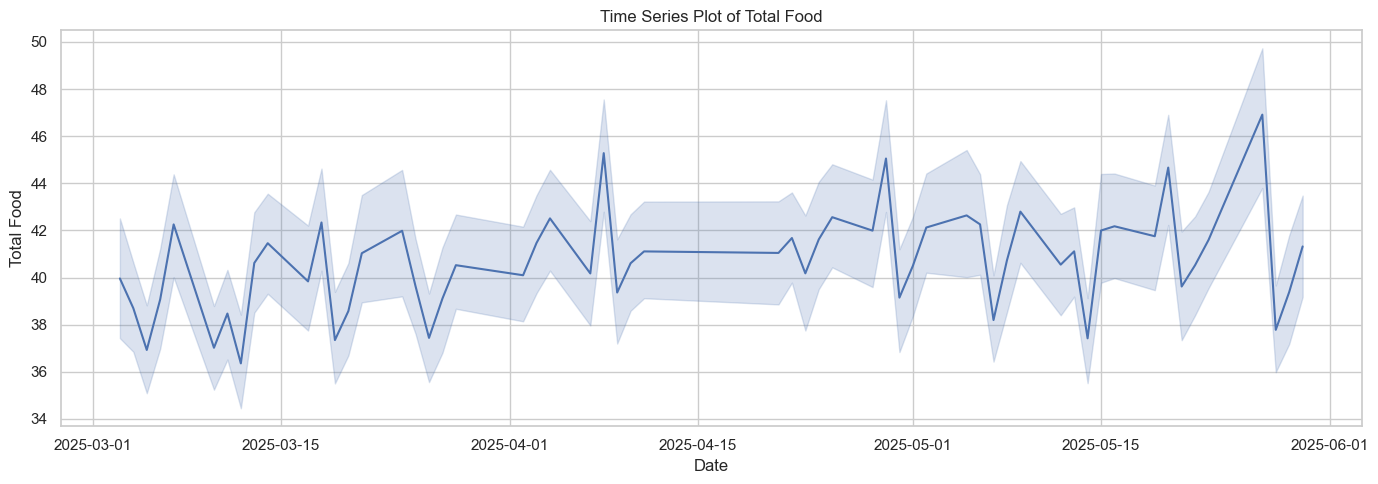

In [22]:
# Plot full time series for a numeric column
plt.figure(figsize=(14, 5))
sns.lineplot(data=dfs, x=dfs.index, y='total')
plt.title("Time Series Plot of Total Food")
plt.xlabel("Date")
plt.ylabel("Total Food")
plt.tight_layout()
plt.show()

---
# Food Popularity

In [31]:
# assigning a different variable name to the dataframes
sales = dfs
breakfast = dfb
lunch = dfl

In [33]:
# converting column names to lowercase
sales.columns = sales.columns.str.lower()
breakfast.columns = breakfast.columns.str.lower()
lunch.columns = lunch.columns.str.lower()

In [34]:
# converting date columns into datatime objects
breakfast['date'] = pd.to_datetime(breakfast['date'])
lunch['date'] = pd.to_datetime(lunch['date'])

In [35]:
# define function to clean numeric columns
def clean_numeric(df, cols):
    for col in cols:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)                                # forcing to string
                .str.replace(r"[\$,%, ]", "", regex=True)   # removing $%, and spaces
                .replace("nan", "0")                        # replacing nan with 0
                .astype(float)                              # converting to float
            )
    return df

In [36]:
#
num_cols = [
    "served_non-reimbursable", "discarded_total", "discarded_cost",
    "subtotal_cost", "left_over_percent_of_offered", "left_over_cost",
    "left_over_total", "production_cost_total"
]
breakfast = clean_numeric(breakfast, num_cols)
lunch = clean_numeric(lunch, num_cols)

In [37]:
# ------- Finding the popular items -------

# From sales
popular_sales = (
    sales.groupby(["time_of_day", "description"])["total"]
    .sum()
    .reset_index()
    .sort_values(["time_of_day", "total"], ascending=[True, False])
)

# From breakfast (by served)
popular_breakfast = (
    breakfast.groupby("name")["served_reimbursable"]
    .sum()
    .reset_index()
    .sort_values("served_reimbursable", ascending=False)
)

# From lunch (by served)
popular_lunch = (
    lunch.groupby("name")["served_reimbursable"]
    .sum()
    .reset_index()
    .sort_values("served_reimbursable", ascending=False)
)

In [38]:
# --- Least discarded (lower is better) ---
if "discarded_total" in breakfast.columns:
    popular_breakfast_low_discarded = (
        breakfast.groupby("name")["discarded_total"]
        .sum()
        .reset_index()
        .sort_values("discarded_total", ascending=True)
    )
else:
    popular_breakfast_low_discarded = None

if "discarded_total" in lunch.columns:
    popular_lunch_low_discarded = (
        lunch.groupby("name")["discarded_total"]
        .sum()
        .reset_index()
        .sort_values("discarded_total", ascending=True)
    )
else:
    popular_lunch_low_discarded = None

In [39]:
print("Top 10 Breakfast Items (by served_total):")
print(popular_breakfast.head(10))

print("\nTop 10 Lunch Items (by served_total):")
print(popular_lunch.head(10))

if popular_breakfast_low_discarded is not None:
    print("\nTop 10 Breakfast Items (least discarded_total):")
    print(popular_breakfast_low_discarded.head(10))

if popular_lunch_low_discarded is not None:
    print("\nTop 10 Lunch Items (least discarded_total):")
    print(popular_lunch_low_discarded.head(10))


Top 10 Breakfast Items (by served_total):
                                                  name  served_reimbursable
7                                   Apple Juice (Each)               413120
99                       Orange Tangerine Juice (Each)               223678
83                       Mini Maple Pancakes (Package)               191648
2                                 1% White Milk (Each)               182381
19                                       Bagel (Bagel)                90662
57                                 Cream Cheese (Each)                69351
71                        Honey Cheerios Cereal (Each)                68135
110               Red Delicious Apple (Each - serving)                66184
55   Cinnamon Toast Crunch Cereal, 25% Less Sugar (...                63168
54                         Cinnamon Chex Cereal (Each)                59297

Top 10 Lunch Items (by served_total):
                                     name  served_reimbursable
169        Fat Free 

In [40]:
# ------- Finding the actual amount of food consumed (served minus discarded) -------

# breakfast
breakfast_net_consumption = (
    breakfast.groupby("name")
    .agg({
        'served_reimbursable': 'sum',
        'discarded_total': 'sum'
    })
    .reset_index()
)

# calculating net consumption
breakfast_net_consumption['net_consumption'] = (
    breakfast_net_consumption['served_reimbursable'] - breakfast_net_consumption['discarded_total']
)

# sorting by net consumption (higher is better)
breakfast_net_consumption = breakfast_net_consumption.sort_values('net_consumption', ascending=False)

# lunch
lunch_net_consumption = (
    lunch.groupby("name")
    .agg({
        'served_reimbursable': 'sum',
        'discarded_total': 'sum'
    })
    .reset_index()
)

# Calculate new consumption
lunch_net_consumption['net_consumption'] = (
    lunch_net_consumption['served_reimbursable'] - lunch_net_consumption['discarded_total']
)

# sorting by net consumption (higher is better)
lunch_net_consumption = lunch_net_consumption.sort_values('net_consumption', ascending=False)

In [42]:
# --- Display Net Consumption Results ---
print("=== NET CONSUMPTION POPULARITY RANKINGS ===")

print("\nTop 15 Breakfast Items (by Net Consumption):")
print("=" * 90)
breakfast_display = breakfast_net_consumption[['name', 'net_consumption', 'served_reimbursable', 'discarded_total']].head(15)
breakfast_display.columns = ['Item Name', 'Net Consumption', 'Total Served', 'Total Discarded']
print(breakfast_display)

print("\nTop 15 Lunch Items (by Net Consumption):")
print("=" * 90)
lunch_display = lunch_net_consumption[['name', 'net_consumption', 'served_reimbursable', 'discarded_total']].head(15)
lunch_display.columns = ['Item Name', 'Net Consumption', 'Total Served', 'Total Discarded']
print(lunch_display)

=== NET CONSUMPTION POPULARITY RANKINGS ===

Top 15 Breakfast Items (by Net Consumption):
                                             Item Name  Net Consumption  \
7                                   Apple Juice (Each)        413020.16   
99                       Orange Tangerine Juice (Each)        223569.49   
83                       Mini Maple Pancakes (Package)        190833.89   
2                                 1% White Milk (Each)        181925.39   
19                                       Bagel (Bagel)         89294.02   
57                                 Cream Cheese (Each)         69295.26   
71                        Honey Cheerios Cereal (Each)         67916.89   
110               Red Delicious Apple (Each - serving)         65913.46   
55   Cinnamon Toast Crunch Cereal, 25% Less Sugar (...         62809.09   
54                         Cinnamon Chex Cereal (Each)         58894.37   
29                        Blueberry Chex Cereal (Each)         49441.68   
64        

In [43]:
# ---------- Finding the items with the highest leftover rate ----------

# breakfast
breakfast_leftover_rate = (
    breakfast.groupby("name")
    .agg({
        'left_over_total': 'sum',
        'offered_reimbursable': 'sum'
    })
    .reset_index()
)

# Calculate leftover rate (percentage)
breakfast_leftover_rate['leftover_rate'] = (
    breakfast_leftover_rate['left_over_total'] / 
    breakfast_leftover_rate['offered_reimbursable'].replace(0, 1)
) * 100

# sorting by leftover rate (higher is worse)
breakfast_leftover_rate = breakfast_leftover_rate.sort_values('leftover_rate', ascending=False)

# lunch
lunch_leftover_rate = (
    lunch.groupby("name")
    .agg({
        'left_over_total': 'sum',
        'offered_reimbursable': 'sum'
    })
    .reset_index()
)

# Calculate leftover rate (percentage)
lunch_leftover_rate['leftover_rate'] = (
    lunch_leftover_rate['left_over_total'] / 
    lunch_leftover_rate['offered_reimbursable'].replace(0, 1)
) * 100

# sorting by leftover rate (higher is worse)
lunch_leftover_rate = lunch_leftover_rate.sort_values('leftover_rate', ascending=False)

In [44]:
# --- Display Leftover Rate Results ---
print("=== LEFTOVER RATE RANKINGS ===")

print("\nTop 15 Breakfast Items (Highest Leftover Rate - Most Waste):")
print("=" * 100)
breakfast_display = breakfast_leftover_rate[['name', 'leftover_rate', 'left_over_total', 'offered_reimbursable']].head(15)
breakfast_display.columns = ['Item Name', 'Leftover Rate (%)', 'Total Left Over', 'Total Offered']
breakfast_display['Leftover Rate (%)'] = breakfast_display['Leftover Rate (%)'].round(2)
print(breakfast_display)

print("\nTop 15 Lunch Items (Highest Leftover Rate - Most Waste):")
print("=" * 100)
lunch_display = lunch_leftover_rate[['name', 'leftover_rate', 'left_over_total', 'offered_reimbursable']].head(15)
lunch_display.columns = ['Item Name', 'Leftover Rate (%)', 'Total Left Over', 'Total Offered']
lunch_display['Leftover Rate (%)'] = lunch_display['Leftover Rate (%)'].round(2)
print(lunch_display)

=== LEFTOVER RATE RANKINGS ===

Top 15 Breakfast Items (Highest Leftover Rate - Most Waste):
                                             Item Name  Leftover Rate (%)  \
62                      Fat Free Chocolate Milk (Each)              98.83   
37   Cereal, Cinnamon Toasters, Malt-O-Meal, IW (Su...              60.26   
64                          Fat Free White Milk (Each)              53.53   
43            Cherry Flavored Dried Cranberries (Each)              53.12   
63        Fat Free Unflavored Shelf-Stable Milk (Each)              52.70   
80   Milk, Lactose Free,  Fat Free, Shelf-Stable (E...              51.24   
96            Orange Flavored Dried Cranberries (Each)              50.00   
132   Watermelon Flavored Dried Cranberries (2 Eaches)              48.05   
17                        Assorted Cereal (Cereal Cup)              47.13   
101             Patty, Chicken, Breaded, WG (2 strips)              46.88   
66                       Frozen, Blueberries (1/2 cup)      

In [45]:
# Calculate overall statistics
print("\n=== OVERALL LEFTOVER STATISTICS ===")
breakfast_total_leftover = breakfast['left_over_total'].sum()
breakfast_total_offered = breakfast['offered_reimbursable'].sum()
breakfast_overall_rate = (breakfast_total_leftover / breakfast_total_offered) * 100

lunch_total_leftover = lunch['left_over_total'].sum()
lunch_total_offered = lunch['offered_reimbursable'].sum()
lunch_overall_rate = (lunch_total_leftover / lunch_total_offered) * 100

print(f"Breakfast Overall Leftover Rate: {breakfast_overall_rate:.2f}%")
print(f"  Total Left Over: {breakfast_total_leftover:,.0f}")
print(f"  Total Offered: {breakfast_total_offered:,.0f}")

print(f"\nLunch Overall Leftover Rate: {lunch_overall_rate:.2f}%")
print(f"  Total Left Over: {lunch_total_leftover:,.0f}")
print(f"  Total Offered: {lunch_total_offered:,.0f}")

print(f"\nCombined Overall Leftover Rate: {((breakfast_total_leftover + lunch_total_leftover) / (breakfast_total_offered + lunch_total_offered)) * 100:.2f}%")



=== OVERALL LEFTOVER STATISTICS ===
Breakfast Overall Leftover Rate: 20.26%
  Total Left Over: 496,886
  Total Offered: 2,451,946

Lunch Overall Leftover Rate: 15.78%
  Total Left Over: 1,845,563
  Total Offered: 11,695,760

Combined Overall Leftover Rate: 16.56%


---
# Time Series Analysis
